In [1]:
import pandas as pd 

df = pd.read_excel('Dataset_SLE_T2T_forML_20241104_for_Giannis_extended(1).xlsx')


In [2]:
filtered_s2k = [col for col in df.columns if 'S2K_item_' in col][:24]
other_drugs = ['Number_mod_severe_drugs', 'Drug_use_score1', 'Drug_use_score2','Delta_treatment_score']


filtered_columns = []

filtered_columns.append(df.SLET2T_ID.name)
filtered_columns.extend(filtered_s2k)

filtered_columns.append(df.Cumulative_prednisolone_intake_daily_category.name)
filtered_columns.extend(other_drugs)

df = df[filtered_columns]


In [10]:
df.iloc[:,25].value_counts()

Cumulative_prednisolone_intake_daily_category
1    1410
0    1353
3     389
2     351
Name: count, dtype: int64

In [57]:
from tensorflow.keras.layers import Input,Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
import tensorflow

s2k = df.iloc[:,1:25]
target = df.iloc[:,25].apply(lambda x: x if x==0 else 1)

x_train, x_test, y_train, y_test = train_test_split(s2k, target, test_size=0.15, shuffle=True)

In [58]:
y_train = tensorflow.keras.utils.to_categorical(y_train)
y_test = tensorflow.keras.utils.to_categorical(y_test)

In [62]:
input_dim = Input((s2k.shape[1],))

fc1 = Dense(32, activation='relu')(input_dim)
do1 = Dropout(0.2)(fc1)
fc2 = Dense(64, activation='relu')(do1)
do2 = Dropout(0.2)(fc2)
fc3 = Dense(128, activation='relu')(do2)
do3 = Dropout(0.2)(fc3)
fc4 = Dense(64, activation='relu')(do3)
fc5 = Dense(32, activation='relu')(fc4)
out = Dense(2, activation='softmax')(fc5)

model = Model(input_dim,out)

model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy'])


Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5919 - loss: 0.6542 - val_accuracy: 0.6274 - val_loss: 0.6240
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6020 - loss: 0.6474 - val_accuracy: 0.6274 - val_loss: 0.6200
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6156 - loss: 0.6358 - val_accuracy: 0.6331 - val_loss: 0.6165
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6224 - loss: 0.6129 - val_accuracy: 0.6331 - val_loss: 0.6132
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6276 - loss: 0.6164 - val_accuracy: 0.6312 - val_loss: 0.6150
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6194 - loss: 0.6321 - val_accuracy: 0.6312 - val_loss: 0.6126
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6273 - loss: 0.6171 - val_accuracy: 0.6274 - val_loss: 0.6201
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6294 - loss: 0.6102 - val_accuracy: 0.6046 - v

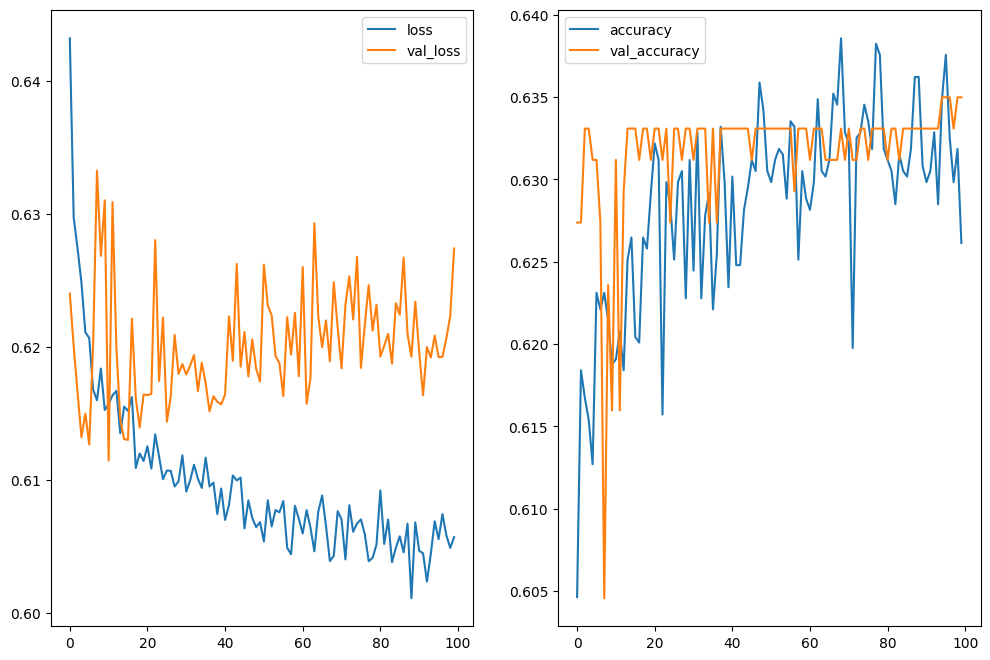

In [63]:
history = model.fit(x_train,y_train,epochs=100,validation_data=(x_test,y_test))

import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss','val_loss'])

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['accuracy','val_accuracy'])

In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

clf = RandomForestClassifier(n_estimators=100)

clf.fit(x_train,y_train)

preds = clf.predict(x_test)

print(classification_report(y_test,preds))

              precision    recall  f1-score   support

           0       0.50      0.40      0.45       196
           1       0.68      0.76      0.72       330

   micro avg       0.63      0.63      0.63       526
   macro avg       0.59      0.58      0.58       526
weighted avg       0.61      0.63      0.62       526
 samples avg       0.63      0.63      0.63       526



In [67]:
def og_autoencoder(input_dim=input_dim, encoding_dim=2):

            input_layer = Input(shape=(input_dim,))

            # Encoder
            encoded = Dense(128, activation='relu', name='128_encoder')(input_layer)
            encoded = Dense(64, activation='relu', name='64_encoder')(encoded)
            encoded = Dense(32, activation='relu', name='32_encoder')(encoded)
            encoded = Dense(encoding_dim, activation='relu', name='output_encoder')(encoded)

            # Decoder
            decoded = Dense(32, activation='relu', name='32_decoder')(encoded)
            decoded = Dense(64, activation='relu', name='64_decoder')(decoded)
            decoded = Dense(128, activation='relu', name='128_decoder')(decoded)
            decoded = Dense(input_dim, activation='tanh', name='output_decoder')(decoded)

            # Autoencoder
            autoencoder = Model(input_layer, decoded)

            autoencoder.compile(optimizer='adam', loss='mse')
            
            return autoencoder

ae = og_autoencoder(input_dim=s2k.shape[1])

In [73]:
s2k_0 = s2k[df.iloc[:,25]==0]
s2k_1 = s2k[df.iloc[:,25]==1]

In [74]:
def is_outside_distribution(prediction, mean, std, threshold=1.5):
    z_score = (prediction - mean) / std
    return abs(z_score) > threshold

In [76]:
from tensorflow.keras.losses import MeanSquaredError
import numpy as np
mse = MeanSquaredError()

ae.compile(optimizer='adam',loss='mse')
ae.fit(s2k_0, s2k_0, epochs=20)
train_preds = ae.predict(s2k_0)
train_losses = [mse(truth,pred) for truth,pred in zip(s2k_0.values,train_preds)]
train_mean = np.mean(train_losses)
train_std = np.std(train_losses)

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0054
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0047
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0046
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0055
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0052 
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0053 
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0049 
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0045
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0046 
Epoch 10/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0050 
Epoch 11/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0047 
Epoch 12/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0051 
Epoch 13/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0051
Epoch 14/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0049
Epoch 15/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0049 
Epoch 16/20

In [81]:
test_preds = ae.predict(s2k_1)
test_losses = [mse(truth,pred) for truth,pred in zip(s2k_1.values,test_preds)]
labels = [is_outside_distribution(loss,train_mean,train_std).numpy() for loss in test_losses]
results = sum(labels)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step


In [84]:
labels

[False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 True,
 True,
 False,
 False,
 False,
 False,
 True,
 True,
 False,
 False,
 True,
 False,
 False,
 False